<div align="center">

<h1> <b> MODELO DE RELAJACIÓN SUPERFICIAL ACTIVADA TÉRMICAMENTE CON INCIDENCIA ANGULAR PARA EL CRECIMIENTO DE PELÍCULAS DELGADAS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y objetivos

Este proyecto estudia qué procesos físicos determinan la morfología de una película delgada de cobre (Cu) depositada sobre vidrio por evaporación térmica en una cámara de vacío. Los mecanismos físicos se incorporan uno a uno en cuadernos independientes, de modo que el efecto de cada uno sobre la morfología pueda distinguirse.

Los cuadernos anteriores supusieron un flujo de partículas estrictamente normal al sustrato. En una cámara de evaporación real, la fuente (crisol o filamento) está a una distancia finita y los átomos salen con una distribución de direcciones, de modo que se desplazan lateralmente durante el vuelo antes de llegar al sustrato.

Este cuarto cuaderno incorpora la **incidencia angular**. Cada partícula recibe un desplazamiento lateral aleatorio que depende de la dispersión angular del haz ($\sigma_\theta$) y de la distancia fuente-sustrato ($L$), y después se relaja con una regla térmica de corto alcance. Como se explica en la sección 2, este operador no altera la estadística de los impactos lejos de los bordes de la malla. Por eso el cuaderno examina también qué efectos aparecen únicamente por el tratamiento de los bordes.

### Objetivos

* Implementar un operador estocástico de dispersión angular que desplace lateralmente el punto de impacto según la geometría de la cámara.
* Estudiar el efecto de $\sigma_\theta$ y de $L$ sobre la rugosidad RMS, separando la contribución del interior de la malla de la de sus bordes.
* Obtener y comparar firmas morfológicas bidimensionales y unidimensionales a distintas dispersiones angulares.

## 2. Marco teórico y modelo físico

### 2.1 Geometría de la incidencia angular

Un átomo de cobre emitido con un ángulo $\theta$ respecto a la normal viaja en línea recta (régimen balístico, alto vacío) hasta el sustrato. Si la fuente está a una altura $L$ sobre el plano del sustrato, el desplazamiento lateral antes del impacto es, por trigonometría elemental,

$$\Delta = L \tan\theta.$$

En el plano $XY$ del sustrato, las desviaciones de cada eje se tratan por separado:

$$\Delta x = L \tan\theta_x, \qquad \Delta y = L \tan\theta_y,$$

donde $\theta_x$ y $\theta_y$ son variables aleatorias normales independientes, $\theta_x, \theta_y \sim \mathcal{N}(0, \sigma_\theta)$. Tanto $L$ como los desplazamientos se miden en unidades del tamaño de celda, de modo que el modelo explora una geometría a la escala de la malla y no las distancias reales de una cámara. La distribución normal de $\theta$ no está acotada: para $\sigma_\theta = 30^\circ$, el $0.3\,\%$ de los ángulos supera $90^\circ$ y la tangente los envía en sentido contrario.

La incidencia oblicua tiene además consecuencias que este modelo no reproduce, como el sombreado geométrico y el crecimiento columnar inclinado, cuyo ángulo se relaciona con el de incidencia mediante la regla de la tangente $\tan\alpha = 2\tan\beta$ (Nieuwenhuizen & Haanstra, 1966).

### 2.2 Algoritmo por evento

Se usa la malla de $N_x \times N_y$ celdas de los cuadernos anteriores, con alturas enteras $h(i, j)$ que cuentan capas efectivas y fronteras abiertas. Cada evento de Monte Carlo sigue estos pasos:

1. **Punto de mira.** Se elige una celda $(x_0, y_0)$ con probabilidad uniforme.
2. **Dispersión angular.** Se sortean $\theta_x$ y $\theta_y$ (en grados), se calculan $\Delta x$ y $\Delta y$ y la celda de impacto es $\left(\mathrm{round}(x_0 + \Delta x),\, \mathrm{round}(y_0 + \Delta y)\right)$. Si cae fuera de la malla, se confina a la celda de borde más cercana (*clipping*).
3. **Difusión superficial de corto alcance.** En cada paso, hasta un máximo de `MAX_DIFFUSION_STEPS`, la partícula considera los vecinos de von Neumann (arriba, abajo, izquierda y derecha) que existan y sean estrictamente más bajos que su celda actual. Si no hay ninguno, se detiene. Si hay alguno, salta a uno de ellos, elegido con igual probabilidad, con probabilidad $P(T) = \min(1, T/T_1)$, donde $T_1 = 500$ K es una temperatura de escala sin calibrar; si el salto falla, se detiene.
4. **Deposición.** La altura de la celda final aumenta una capa: $h(i^*, j^*) \leftarrow h(i^*, j^*) + 1$.

La regla de difusión no coincide con la del cuaderno 3. Aquí la partícula solo desciende, mientras que allí podía ascender una capa; no hace falta una lista de celdas visitadas, porque con descenso estricto no puede volver a una celda ya visitada; y la probabilidad de salto es $\min(1, T/T_1)$ en lugar de $T/(T+T_0)$. Por ello los resultados de este cuaderno no son directamente comparables con los del cuaderno 3.

### 2.3 Efecto del confinamiento y magnitudes de caracterización

En una malla infinita, sumar a una posición uniforme un desplazamiento aleatorio independiente da otra posición uniforme: la dispersión angular no cambia la distribución de los impactos. En la malla finita del modelo el resultado difiere solo cerca de los bordes, por dos razones. Las partículas cuya trayectoria las llevaría fuera de la malla se acumulan en las celdas de borde por el confinamiento, y las celdas próximas al borde dejan de recibir partículas de puntos de mira exteriores, que no existen.

La morfología se caracteriza con el **espesor medio** $\overline{h}$ y la **rugosidad RMS** $W$ (desviación estándar de las alturas), ambos en capas, como en los cuadernos anteriores. Como $W$ calculada sobre toda la malla mezcla la contribución del interior, donde la dispersión angular no debería influir, con la de los bordes, se define además:

* La **rugosidad interior** $W_{\mathrm{int}}$, desviación estándar de las alturas en la región central que excluye un margen de `MARGEN_INTERIOR` celdas por cada lado.
* La **fracción de partículas en el anillo exterior**, es decir, la proporción de partículas que termina en las celdas de la primera y última fila y columna, que forman el $2\,\%$ de la malla.

### 2.4 Referencias analíticas

Sea $M = N_x N_y$ el número de celdas y $N$ el número de eventos. Cada evento añade una capa, de modo que $\sum h = N$ y $\overline{h}_{\mathrm{teo}} = N/M$, relación exacta que expresa la conservación del número de partículas.

Sin difusión ($T = 0$, $P = 0$), el modelo se reduce a la deposición aleatoria (RD) con un desplazamiento lateral de cada partícula. Si el argumento de la sección 2.3 es correcto, el interior conserva entonces la estadística de RD: las alturas siguen una distribución de Poisson de media $\lambda = \overline{h}$ y $W_{\mathrm{int}} = \sqrt{\overline{h}}$ (Barabási & Stanley, 1995, cap. 4). Para una región de $M_{\mathrm{int}}$ celdas independientes, la rugosidad de una realización fluctúa alrededor de ese valor con desviación típica $\sigma_{\mathrm{int}} \approx \sqrt{(1 + 2\lambda)/(4 M_{\mathrm{int}})}$, que se obtiene del cuarto momento central de la distribución de Poisson. Este límite permite validar el código.

Con difusión no se usa una predicción analítica de $W$. La validación se apoya en la conservación de partículas, en el límite $T = 0$ y en la comparación con la referencia RD.

## 3. Librerías y configuración

El cálculo numérico usa NumPy (Harris et al., 2020) y las tablas de resultados se organizan con pandas (McKinney, 2010). Los ciclos de dispersión angular, difusión y cálculo de métricas se compilan con Numba (Lam et al., 2015) cuando la librería está instalada; si no lo está, las mismas funciones se ejecutan como Python puro, con más lentitud pero con las mismas propiedades estadísticas. SciPy (Virtanen et al., 2020) aporta la distribución de Poisson de referencia y Matplotlib (Hunter, 2007) se encarga de la visualización.

Numba mantiene un generador de números pseudoaleatorios propio, con un estado independiente del de NumPy: sembrar uno no modifica al otro (Numba, s. f.). Por ello cada simulación fija su semilla dentro de la función compilada (sección 5). Las semillas de las distintas simulaciones se derivan de una única semilla con `SeedSequence` de NumPy, de modo que cada una es independiente y reproducible por separado. Las secuencias de Numba y de NumPy no tienen por qué coincidir para una misma semilla, de manera que una realización concreta solo es reproducible dentro de un mismo modo de ejecución.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson

# Numba es una dependencia opcional de aceleración. Si no está instalada, las
# funciones numéricas se ejecutan sin compilar: el resultado es estadísticamente
# equivalente, aunque más lento.
try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ImportError:
    NUMBA_DISPONIBLE = False

    def njit(*args, **kwargs):
        """ Sustituto de ``numba.njit`` que deja la función sin compilar.

        Admite tanto la forma ``@njit`` como la forma ``@njit(...)``.
        """
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorador(funcion):
            return funcion

        return decorador

if not NUMBA_DISPONIBLE:
    print("Numba no está disponible: la simulación se ejecutará en Python puro (más lenta).")

# Mostrar todas las columnas de las tablas de resultados
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Estilo de las figuras. La resolución de guardado (300 dpi) es la adecuada
# para insertarlas en un informe.
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120,
    'savefig.dpi': 300
})

## 4. Parámetros del sistema

Las dimensiones de la malla y las distancias se dan en celdas, el número de eventos en partículas depositadas, las temperaturas en kelvin, los ángulos en grados y las alturas en capas. Con 160 000 eventos sobre $200 \times 200$ celdas, el espesor medio es de 4 capas. Los cuadernos 1 a 3 depositaron 10, 10 y 2.5 capas, así que la comparación con RD se hace aquí con la referencia analítica evaluada a este espesor.

In [2]:
# Configuración geométrica del sustrato (número de celdas en cada dirección)
NX = 200
NY = 200

# Condición base
N_EVENTOS = 160_000         # partículas por simulación (espesor medio N_EVENTOS / (NX * NY) = 4 capas)
TEMPERATURE = 400           # temperatura del sustrato (K)
T_ESCALA = 500              # temperatura de escala de P(T) = min(1, T / T_ESCALA), en kelvin
MAX_DIFFUSION_STEPS = 5     # número máximo de saltos por partícula
GUARDAR_CADA = 2_000        # intervalo de muestreo de la evolución temporal, en eventos
SOURCE_DISTANCE = 40        # distancia vertical fuente-sustrato L, en celdas
SIGMA_ANGLE = 5             # dispersión angular sigma_theta, en grados

# Experimento I: barrido de la dispersión angular (con L = SOURCE_DISTANCE)
ANGLE_VALUES = [0, 2, 5, 10, 15, 20, 30]

# Experimento II: barrido de la distancia fuente-sustrato (con sigma_theta = SIGMA_FIJO)
DISTANCE_VALUES = [10, 20, 40, 60, 80]
SIGMA_FIJO = 10

# Réplicas independientes por cada valor de los barridos
N_REPLICAS = 5

# Dispersiones angulares cuyas superficies se comparan visualmente
SIGMAS_A_MOSTRAR = [0, 5, 10, 20, 30]

# Margen, en celdas, que se excluye a cada lado para calcular la rugosidad interior
MARGEN_INTERIOR = 50

# Semilla única de la que se derivan las semillas de todas las simulaciones (ver sección 3)
SEMILLA = 42

if not (1 <= MARGEN_INTERIOR and 2 * MARGEN_INTERIOR < min(NX, NY)):
    raise ValueError("MARGEN_INTERIOR debe ser positivo y menor que la mitad de la malla.")

## 5. Funciones del modelo

La función `calcular_metricas_numba` obtiene $\overline{h}$ y $W$ con dos recorridos de la malla: primero la media y después las desviaciones respecto a ella. Este esquema evita la cancelación numérica que aparece al restar $\langle h^2 \rangle - \langle h \rangle^2$ cuando la media es grande frente a la dispersión.

La función `aplicar_dispersion_angular` calcula la celda de impacto de una partícula tras su vuelo balístico, y `difundir_particula_angular` aplica la relajación por descenso. Esta última recorre la vecindad dos veces, primero para contar los vecinos más bajos y luego para localizar el elegido, en lugar de construir un arreglo de candidatos en cada salto.

La función `ejecutar_simulacion_angular_con_historial` implementa el ciclo Monte Carlo y registra las métricas cada `guardar_cada` eventos; `ejecutar_simulacion_angular` la invoca sin conservar el historial. El ciclo es estrictamente secuencial: cada partícula se relaja sobre el estado que dejaron las anteriores y todas modifican la misma matriz de alturas, por lo que una simulación no se paraleliza. Las réplicas son independientes entre sí y se ejecutan en serie.

Por último, `resumir_superficie` calcula con NumPy, sobre una superficie ya terminada, las métricas globales, las del interior y las del anillo exterior de la sección 2.3.

In [3]:
@njit
def calcular_metricas_numba(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS de una superficie.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Altura de cada celda, en capas.
    nx, ny : int
        Número de celdas en cada dirección.

    Devuelve
    --------
    espesor : float
        Altura media, en capas.
    rugosidad : float
        Desviación estándar poblacional de las alturas (divisor nx * ny), en capas.
    """
    # Se calcula primero la media y después las desviaciones respecto a ella
    # (dos pasadas). Restar <h^2> - <h>^2 en una sola pasada perdería precisión
    # cuando la media es grande frente a la dispersión.
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)

    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))

    return espesor, rugosidad

In [4]:
@njit
def aplicar_dispersion_angular(x, y, nx, ny, dist_fuente, sigma_ang):
    """Calcula la celda de impacto de una partícula tras su vuelo balístico.

    Los ángulos de emisión theta_x y theta_y se sortean de una distribución normal
    de media cero y desviación sigma_ang (en grados). El desplazamiento lateral
    es dist_fuente * tan(theta) en cada eje, en unidades de celda. Si la celda de
    impacto cae fuera de la malla, se confina a la celda de borde más cercana.

    Parámetros
    ----------
    x, y : int
        Celda del punto de mira, antes de la dispersión.
    nx, ny : int
        Número de celdas en cada dirección.
    dist_fuente : float
        Distancia vertical fuente-sustrato, en celdas.
    sigma_ang : float
        Desviación estándar de los ángulos de emisión, en grados.

    Devuelve
    --------
    new_x, new_y : int
        Índices de la celda de impacto.
    """
    # Muestreo normal en grados
    theta_x = np.random.normal(0.0, sigma_ang)
    theta_y = np.random.normal(0.0, sigma_ang)

    # Conversión a radianes
    rad_x = theta_x * np.pi / 180.0
    rad_y = theta_y * np.pi / 180.0

    # Desplazamiento lateral del viaje balístico
    dx = dist_fuente * np.tan(rad_x)
    dy = dist_fuente * np.tan(rad_y)

    # Celda de impacto: posición redondeada
    new_x = int(round(x + dx))
    new_y = int(round(y + dy))

    # Confinamiento en las fronteras del sustrato (clipping). Las partículas
    # que caerían fuera se acumulan en las celdas de borde.
    if new_x < 0:
        new_x = 0
    if new_x >= nx:
        new_x = nx - 1
    if new_y < 0:
        new_y = 0
    if new_y >= ny:
        new_y = ny - 1

    return new_x, new_y

In [5]:
@njit
def difundir_particula_angular(superficie, x, y, nx, ny, temp, t_escala, max_pasos):
    """Aplica la difusión de corto alcance por descenso a una partícula que impacta en (x, y).

    En cada paso, la partícula salta con probabilidad P = min(1, temp / t_escala)
    a uno de sus vecinos de von Neumann estrictamente más bajos, elegido con igual
    probabilidad. Se detiene si no hay vecinos más bajos, si el salto falla o si
    alcanza max_pasos saltos. Las fronteras son abiertas.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas actuales, en capas. La función no las modifica.
    x, y : int
        Celda de impacto.
    nx, ny : int
        Número de celdas en cada dirección.
    temp : float
        Temperatura del sustrato, en kelvin.
    t_escala : float
        Temperatura de escala de la probabilidad de salto, en kelvin.
    max_pasos : int
        Número máximo de saltos.

    Devuelve
    --------
    curr_x, curr_y : int
        Índices de la celda que recibe la partícula.
    """
    curr_x = x
    curr_y = y

    # Desplazamientos de von Neumann: izquierda, derecha, abajo, arriba
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)

    # Probabilidad de salto según la temperatura
    prob_difusion = temp / t_escala
    if prob_difusion > 1.0:
        prob_difusion = 1.0

    for _ in range(max_pasos):
        curr_h = superficie[curr_x, curr_y]

        # Primer recorrido: número de vecinos estrictamente más bajos.
        conteo_validos = 0
        for i in range(4):
            nx_c = curr_x + dx[i]
            ny_c = curr_y + dy[i]
            if 0 <= nx_c < nx and 0 <= ny_c < ny:
                if superficie[nx_c, ny_c] < curr_h:
                    conteo_validos += 1

        # Sin microvalles en la vecindad, la partícula se deposita.
        if conteo_validos == 0:
            break

        # Intento de salto. Un segundo recorrido localiza al vecino elegido sin
        # crear arreglos temporales en cada paso.
        if np.random.random() < prob_difusion:
            idx = np.random.randint(0, conteo_validos)
            next_x = curr_x
            next_y = curr_y
            contador = 0
            for i in range(4):
                nx_c = curr_x + dx[i]
                ny_c = curr_y + dy[i]
                if 0 <= nx_c < nx and 0 <= ny_c < ny:
                    if superficie[nx_c, ny_c] < curr_h:
                        if contador == idx:
                            next_x = nx_c
                            next_y = ny_c
                            break
                        contador += 1
            curr_x = next_x
            curr_y = next_y
        else:
            break

    return curr_x, curr_y

In [6]:
@njit
def ejecutar_simulacion_angular_con_historial(nx, ny, n_eventos, temp, t_escala, max_pasos,
                                              dist_fuente, sigma_ang, guardar_cada, semilla):
    """Ejecuta la simulación con incidencia angular y registra la evolución temporal.

    Cada evento elige un punto de mira uniforme, aplica la dispersión angular
    (ver ``aplicar_dispersion_angular``), relaja la partícula
    (ver ``difundir_particula_angular``) y la deposita.

    Parámetros
    ----------
    nx, ny : int
        Número de celdas en cada dirección.
    n_eventos : int
        Número total de eventos, igual al número de partículas depositadas.
    temp, t_escala : float
        Temperatura del sustrato y temperatura de escala de la probabilidad de salto, en kelvin.
    max_pasos : int
        Número máximo de saltos por partícula.
    dist_fuente : float
        Distancia vertical fuente-sustrato, en celdas.
    sigma_ang : float
        Desviación estándar de los ángulos de emisión, en grados.
    guardar_cada : int
        Intervalo de muestreo, en eventos, de las métricas temporales.
    semilla : int
        Semilla del generador pseudoaleatorio.

    Devuelve
    --------
    superficie : ndarray int32, forma (nx, ny)
        Alturas finales, en capas.
    hist_eventos : ndarray int32
        Número de eventos transcurridos en cada muestreo.
    hist_espesor, hist_rugosidad : ndarray float64
        Espesor medio y rugosidad RMS, en capas, en cada muestreo.
    """
    if nx <= 0 or ny <= 0:
        raise ValueError("nx y ny deben ser positivos.")
    if guardar_cada <= 0 or guardar_cada > n_eventos:
        raise ValueError("Se requiere 0 < guardar_cada <= n_eventos.")
    if temp < 0 or t_escala <= 0 or max_pasos < 0:
        raise ValueError("Se requiere temp >= 0, t_escala > 0 y max_pasos >= 0.")
    if dist_fuente < 0 or sigma_ang < 0:
        raise ValueError("Se requiere dist_fuente >= 0 y sigma_ang >= 0.")

    # En Numba, np.random.seed solo actúa sobre el generador de Numba si se
    # llama dentro de una función compilada; por eso la semilla se fija aquí.
    np.random.seed(semilla)

    superficie = np.zeros((nx, ny), dtype=np.int32)

    # Arreglos de tamaño fijo para el historial: evitan crecer listas dentro
    # del ciclo compilado.
    tamano_hist = n_eventos // guardar_cada
    hist_eventos = np.zeros(tamano_hist, dtype=np.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=np.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=np.float64)

    idx_hist = 0
    for evento in range(1, n_eventos + 1):
        # Punto de mira, equiprobable e independiente de la altura actual.
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)

        # Vuelo balístico y relajación. La relajación depende del estado actual
        # de la superficie, por lo que los eventos deben procesarse en orden.
        x_arr, y_arr = aplicar_dispersion_angular(x_i, y_i, nx, ny, dist_fuente, sigma_ang)
        x_f, y_f = difundir_particula_angular(superficie, x_arr, y_arr, nx, ny, temp, t_escala, max_pasos)
        superficie[x_f, y_f] += 1

        # Las métricas se evalúan sobre el estado acumulado de la superficie.
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1

    return superficie, hist_eventos, hist_espesor, hist_rugosidad


@njit
def ejecutar_simulacion_angular(nx, ny, n_eventos, temp, t_escala, max_pasos, dist_fuente, sigma_ang, semilla):
    """Ejecuta la simulación con incidencia angular y devuelve solo la superficie final.

    Equivale a ``ejecutar_simulacion_angular_con_historial`` con una única
    muestra temporal al final; los parámetros son los mismos, salvo ``guardar_cada``.
    """
    superficie, _, _, _ = ejecutar_simulacion_angular_con_historial(
        nx, ny, n_eventos, temp, t_escala, max_pasos, dist_fuente, sigma_ang, n_eventos, semilla
    )
    return superficie

In [7]:
def resumir_superficie(superficie, margen):
    """Resume una superficie terminada: métricas globales, del interior y del anillo exterior.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas finales, en capas.
    margen : int
        Celdas que se excluyen a cada lado para definir la región interior.

    Devuelve
    --------
    dict con el espesor y la rugosidad globales, el espesor y la rugosidad de la
    región interior, las alturas máxima y mínima, la fracción de partículas que
    termina en el anillo exterior (primera y última fila y columna) y la altura
    media de ese anillo.
    """
    nx, ny = superficie.shape
    interior = superficie[margen:nx - margen, margen:ny - margen]
    anillo = np.ones(superficie.shape, dtype=bool)
    anillo[1:-1, 1:-1] = False
    return {
        "espesor": superficie.mean(),
        "rugosidad": superficie.std(),
        "espesor_int": interior.mean(),
        "rugosidad_int": interior.std(),
        "maximo": superficie.max(),
        "minimo": superficie.min(),
        "frac_anillo": superficie[anillo].sum() / superficie.sum(),
        "altura_anillo": superficie[anillo].mean(),
    }

## 6. Condición base y validación

Se ejecuta la condición base ($\sigma_\theta$ = `SIGMA_ANGLE`, $L$ = `SOURCE_DISTANCE`, $T$ = `TEMPERATURE`) con historial temporal. En cada simulación se verifica que $\sum h = N$. Después se valida el límite sin difusión ($T = 0$ K), en el que el interior debe conservar la estadística de RD aunque haya dispersión angular. Para $\sigma_\theta = 0$ y $\sigma_\theta$ = `SIGMA_ANGLE`, la rugosidad interior media de `N_REPLICAS` réplicas se compara con $\sqrt{\overline{h}}$ mediante

$$z = \frac{\overline{W}_{\mathrm{int}} - \sqrt{\overline{h}}}{\sigma_{\mathrm{int}}/\sqrt{N_{\mathrm{réplicas}}}},$$

y se considera compatible cuando $|z| \leq 3$.

In [8]:
n_celdas = NX * NY
espesor_teo = N_EVENTOS / n_celdas
rugosidad_rd = np.sqrt(espesor_teo)                 # RD: W = sqrt(h)

# Semillas independientes y reproducibles derivadas de SEMILLA: una secuencia para la
# condición base, otra para la validación, otra para cada barrido y otra para la comparación.
secuencias = np.random.SeedSequence(SEMILLA).spawn(5)
semilla_base = int(secuencias[0].generate_state(1)[0])
semillas_validacion = secuencias[1].generate_state(2 * N_REPLICAS)
semillas_angulos = [s.generate_state(N_REPLICAS) for s in secuencias[2].spawn(len(ANGLE_VALUES))]
semillas_distancias = [s.generate_state(N_REPLICAS) for s in secuencias[3].spawn(len(DISTANCE_VALUES))]
semillas_comparativas = secuencias[4].generate_state(len(SIGMAS_A_MOSTRAR))


def simular_y_resumir(temp, dist, sigma, semilla):
    """Simula una réplica, verifica la conservación de partículas y devuelve su resumen y su superficie."""
    superficie = ejecutar_simulacion_angular(
        NX, NY, N_EVENTOS, temp, T_ESCALA, MAX_DIFFUSION_STEPS, dist, sigma, int(semilla)
    )
    # Cada evento añade exactamente una capa, aunque la partícula se relocalice: si la
    # suma no coincide con N_EVENTOS, el resultado es incorrecto aunque no se lance
    # ninguna excepción.
    if superficie.sum() != N_EVENTOS:
        raise RuntimeError(f"La suma de alturas no coincide con N_EVENTOS (T = {temp} K, sigma = {sigma}, L = {dist}).")
    return resumir_superficie(superficie, MARGEN_INTERIOR), superficie


print("Ejecutando la simulación de la condición base...")
superficie_base, hist_ev, hist_esp, hist_rug = ejecutar_simulacion_angular_con_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, T_ESCALA, MAX_DIFFUSION_STEPS,
    SOURCE_DISTANCE, SIGMA_ANGLE, GUARDAR_CADA, semilla_base
)
print("Simulación finalizada.")

if superficie_base.sum() != N_EVENTOS:
    raise RuntimeError("La suma de alturas no coincide con el número de partículas depositadas.")
resumen_base = resumir_superficie(superficie_base, MARGEN_INTERIOR)

Ejecutando la simulación de la condición base...
Simulación finalizada.


In [9]:
ANCHO = 66


def fila(etiqueta, valor):
    print(f"{etiqueta:<35}: {valor}")


fraccion_celdas_anillo = 100 * (2 * (NX + NY) - 4) / n_celdas

print("=" * ANCHO)
print("MÉTRICAS DE LA PELÍCULA CON INCIDENCIA ANGULAR (BASE)".center(ANCHO))
print("=" * ANCHO)
fila("Dimensiones del sustrato", f"{NX} x {NY} celdas")
fila("Partículas depositadas", N_EVENTOS)
fila("Altura máxima alcanzada", f"{resumen_base['maximo']} capas")
fila("Altura mínima alcanzada", f"{resumen_base['minimo']} capas")
print("-" * ANCHO)
fila("Espesor medio simulado", f"{resumen_base['espesor']:.4f} capas")
fila("Espesor medio teórico", f"{espesor_teo:.4f} capas")
print("-" * ANCHO)
fila("Rugosidad RMS global", f"{resumen_base['rugosidad']:.4f} capas")
fila("Rugosidad RMS interior", f"{resumen_base['rugosidad_int']:.4f} capas")
fila("Rugosidad RMS de referencia (RD)", f"{rugosidad_rd:.4f} capas")
fila("Cociente W(global) / W(RD)", f"{resumen_base['rugosidad'] / rugosidad_rd:.3f}")
print("-" * ANCHO)
fila("Partículas en el anillo exterior", f"{100 * resumen_base['frac_anillo']:.2f} %")
fila("Celdas del anillo exterior", f"{fraccion_celdas_anillo:.2f} %")
print("=" * ANCHO)

      MÉTRICAS DE LA PELÍCULA CON INCIDENCIA ANGULAR (BASE)       
Dimensiones del sustrato           : 200 x 200 celdas
Partículas depositadas             : 160000
Altura máxima alcanzada            : 9 capas
Altura mínima alcanzada            : 1 capas
------------------------------------------------------------------
Espesor medio simulado             : 4.0000 capas
Espesor medio teórico              : 4.0000 capas
------------------------------------------------------------------
Rugosidad RMS global               : 0.7301 capas
Rugosidad RMS interior             : 0.6997 capas
Rugosidad RMS de referencia (RD)   : 2.0000 capas
Cociente W(global) / W(RD)         : 0.365
------------------------------------------------------------------
Partículas en el anillo exterior   : 2.60 %
Celdas del anillo exterior         : 1.99 %


In [10]:
# Validación del límite T = 0 K: sin difusión, el interior debe conservar la estadística de RD
lado_interior = NX - 2 * MARGEN_INTERIOR, NY - 2 * MARGEN_INTERIOR
n_celdas_int = lado_interior[0] * lado_interior[1]
sigma_int = np.sqrt((1 + 2 * espesor_teo) / (4 * n_celdas_int))    # fluctuación de W_int en una realización
error_estandar = sigma_int / np.sqrt(N_REPLICAS)                   # fluctuación de la media de las réplicas

print("=" * ANCHO)
print("VALIDACIÓN DEL LÍMITE T = 0 K (INTERIOR = RD)".center(ANCHO))
print("=" * ANCHO)
z_validacion = []
for k, sigma in enumerate((0, SIGMA_ANGLE)):
    semillas = semillas_validacion[k * N_REPLICAS:(k + 1) * N_REPLICAS]
    rug_int = np.array([
        simular_y_resumir(0, SOURCE_DISTANCE, sigma, s)[0]["rugosidad_int"] for s in semillas
    ])
    z = (rug_int.mean() - rugosidad_rd) / error_estandar
    z_validacion.append(z)
    fila(f"sigma = {sigma}°: W interior (media)", f"{rug_int.mean():.4f} capas")
    fila(f"sigma = {sigma}°: desviación z", f"{z:+.2f}")
fila("W interior teórica (RD)", f"{rugosidad_rd:.4f} capas")
fila("Fluctuación esperada de la media", f"{error_estandar:.4f} capas")
print("=" * ANCHO)

if max(abs(z) for z in z_validacion) <= 3:
    print("Sin difusión, el interior es compatible con RD para ambas dispersiones (|z| <= 3).")
else:
    print("Sin difusión, el interior se aparta de RD (|z| > 3): revisar el generador y el algoritmo.")

          VALIDACIÓN DEL LÍMITE T = 0 K (INTERIOR = RD)           
sigma = 0°: W interior (media)     : 2.0040 capas
sigma = 0°: desviación z           : +0.59
sigma = 5°: W interior (media)     : 1.9935 capas
sigma = 5°: desviación z           : -0.96
W interior teórica (RD)            : 2.0000 capas
Fluctuación esperada de la media   : 0.0067 capas
Sin difusión, el interior es compatible con RD para ambas dispersiones (|z| <= 3).


## 7. Experimentos computacionales

El experimento I barre la dispersión angular $\sigma_\theta$ con $L$ y $T$ fijos, y el experimento II barre la distancia fuente-sustrato $L$ con $\sigma_\theta$ fijo. Cada valor se simula con `N_REPLICAS` réplicas independientes. Las tablas resumen la media y la desviación estándar muestral (ddof = 1) entre réplicas de la rugosidad global, la rugosidad interior y las magnitudes de borde. Después se generan las superficies individuales que se comparan visualmente en la sección 8.

In [11]:
# Experimento I: barrido de la dispersión angular
resultados_angulos = []

for sigma, semillas in zip(ANGLE_VALUES, semillas_angulos):
    print(f"Evaluando dispersión angular: sigma = {sigma}°...")
    resumenes = [simular_y_resumir(TEMPERATURE, SOURCE_DISTANCE, sigma, s)[0] for s in semillas]
    col = lambda clave: np.array([r[clave] for r in resumenes])

    resultados_angulos.append({
        "Sigma (°)": sigma,
        "Espesor medio (capas)": col("espesor").mean(),
        "Rugosidad global (capas)": col("rugosidad").mean(),
        "Desv. rugosidad global": col("rugosidad").std(ddof=1),
        "Rugosidad interior (capas)": col("rugosidad_int").mean(),
        "Desv. rugosidad interior": col("rugosidad_int").std(ddof=1),
        "Espesor interior (capas)": col("espesor_int").mean(),
        "Altura máxima media": col("maximo").mean(),
        "Altura mínima media": col("minimo").mean(),
        "Partículas en el anillo (%)": 100 * col("frac_anillo").mean(),
    })

df_angulos = pd.DataFrame(resultados_angulos)
# Tabla resumen del experimento I
df_angulos.round(3)

Evaluando dispersión angular: sigma = 0°...
Evaluando dispersión angular: sigma = 2°...
Evaluando dispersión angular: sigma = 5°...
Evaluando dispersión angular: sigma = 10°...
Evaluando dispersión angular: sigma = 15°...
Evaluando dispersión angular: sigma = 20°...
Evaluando dispersión angular: sigma = 30°...


,Sigma (°),Espesor medio (capas),Rugosidad global (capas),Desv. rugosidad global,Rugosidad interior (capas),Desv. rugosidad interior,Espesor interior (capas),Altura máxima media,Altura mínima media,Partículas en el anillo (%)
0,0,4.0,0.705,0.003,0.703,0.009,3.998,7.6,1.6,1.986
1,2,4.0,0.703,0.004,0.703,0.013,3.997,8.0,1.8,2.077
2,5,4.0,0.731,0.004,0.699,0.008,3.999,8.6,1.8,2.578
3,10,4.0,0.883,0.005,0.704,0.010,4.001,15.6,1.0,3.431
4,15,4.0,1.137,0.008,0.700,0.006,3.997,25.6,1.0,4.315
5,20,4.0,1.497,0.014,0.700,0.008,3.988,44.8,0.6,5.265
6,30,4.0,2.796,0.043,0.694,0.007,3.755,117.6,0.0,8.026


In [12]:
# Experimento II: barrido de la distancia fuente-sustrato
resultados_distancias = []

for dist, semillas in zip(DISTANCE_VALUES, semillas_distancias):
    print(f"Evaluando geometría de cámara: L = {dist} celdas...")
    resumenes = [simular_y_resumir(TEMPERATURE, dist, SIGMA_FIJO, s)[0] for s in semillas]
    col = lambda clave: np.array([r[clave] for r in resumenes])

    resultados_distancias.append({
        "Distancia L (celdas)": dist,
        "Rugosidad global (capas)": col("rugosidad").mean(),
        "Desv. rugosidad global": col("rugosidad").std(ddof=1),
        "Rugosidad interior (capas)": col("rugosidad_int").mean(),
        "Desv. rugosidad interior": col("rugosidad_int").std(ddof=1),
        "Partículas en el anillo (%)": 100 * col("frac_anillo").mean(),
    })

df_distancias = pd.DataFrame(resultados_distancias)
# Tabla resumen del experimento II
df_distancias.round(3)

Evaluando geometría de cámara: L = 10 celdas...
Evaluando geometría de cámara: L = 20 celdas...
Evaluando geometría de cámara: L = 40 celdas...
Evaluando geometría de cámara: L = 60 celdas...
Evaluando geometría de cámara: L = 80 celdas...


,Distancia L (celdas),Rugosidad global (capas),Desv. rugosidad global,Rugosidad interior (capas),Desv. rugosidad interior,Partículas en el anillo (%)
0,10,0.704,0.003,0.701,0.005,2.164
1,20,0.736,0.005,0.708,0.013,2.606
2,40,0.879,0.008,0.704,0.011,3.419
3,60,1.109,0.012,0.708,0.008,4.220
4,80,1.404,0.012,0.705,0.005,5.018


In [13]:
# Superficies individuales para la comparación morfológica multiángulo
superficies_comparativas = {}
for sigma, semilla in zip(SIGMAS_A_MOSTRAR, semillas_comparativas):
    _, superficies_comparativas[sigma] = simular_y_resumir(TEMPERATURE, SOURCE_DISTANCE, sigma, semilla)
print("Superficies comparativas generadas para sigma =", SIGMAS_A_MOSTRAR)

Superficies comparativas generadas para sigma = [0, 5, 10, 20, 30]


## 8. Visualización de resultados

Las cuatro primeras figuras muestran las firmas morfológicas de la condición base. Las dos siguientes presentan la rugosidad global y la rugosidad interior en función de $\sigma_\theta$ y de $L$, con barras de error que indican la desviación estándar entre réplicas. Las cuatro últimas comparan superficies a distintas dispersiones angulares. En los perfiles de la fila central, la banda $\pm W$ se calcula con toda la fila y por eso incluye las celdas de borde. Además de mostrarse en el cuaderno, cada figura se guarda como archivo PNG en el directorio de trabajo.

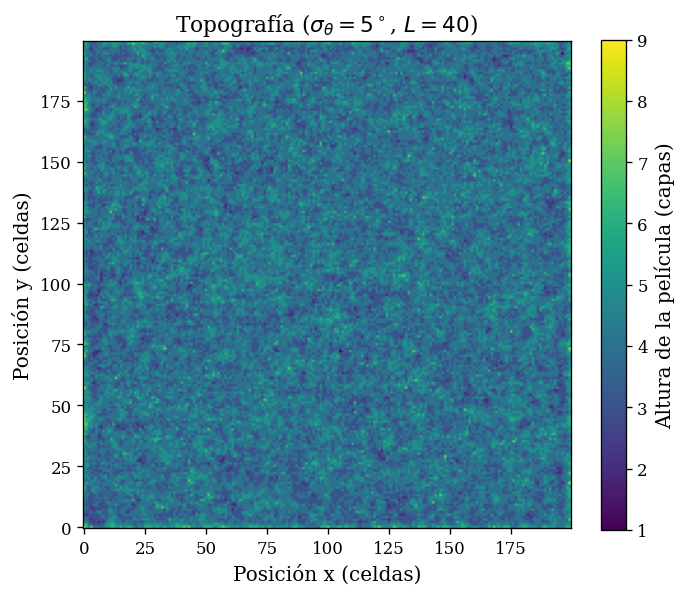

In [14]:
# Topografía de la condición base
fig, ax = plt.subplots(figsize=(6, 5))
# Se transpone la matriz para que el eje horizontal sea x (primer índice de la
# malla) y el vertical sea y (segundo índice).
imagen = ax.imshow(superficie_base.T, origin="lower", cmap="viridis")
fig.colorbar(imagen, ax=ax, label="Altura de la película (capas)")
ax.set_xlabel("Posición x (celdas)")
ax.set_ylabel("Posición y (celdas)")
ax.set_title(rf"Topografía ($\sigma_\theta = {SIGMA_ANGLE}^\circ$, $L = {SOURCE_DISTANCE}$)")
fig.tight_layout()
fig.savefig("angular_topografia_2d.png", bbox_inches="tight")
plt.show()

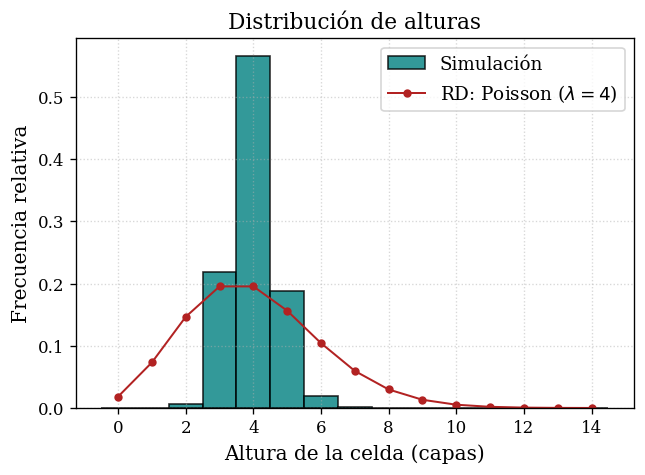

In [15]:
# Distribución de alturas de la condición base frente a la estadística de Poisson del modelo RD
altura_sup = max(int(resumen_base["maximo"]), int(np.ceil(espesor_teo + 5 * rugosidad_rd)))
bordes = np.arange(0, altura_sup + 2) - 0.5          # un intervalo de anchura unidad por altura entera
alturas_enteras = np.arange(0, altura_sup + 1)

fig, ax = plt.subplots(figsize=(6, 4))
# Con density=True e intervalos de anchura unidad, la altura de cada barra es la
# frecuencia relativa de esa altura.
ax.hist(
    superficie_base.ravel(), bins=bordes, density=True, color="teal",
    edgecolor="black", alpha=0.8, label="Simulación",
)
ax.plot(
    alturas_enteras, poisson.pmf(alturas_enteras, espesor_teo), "o-", color="firebrick",
    markersize=4, linewidth=1.2, label=rf"RD: Poisson ($\lambda = {espesor_teo:g}$)",
)
ax.set_xlabel("Altura de la celda (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribución de alturas")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
fig.savefig("angular_histograma.png", bbox_inches="tight")
plt.show()

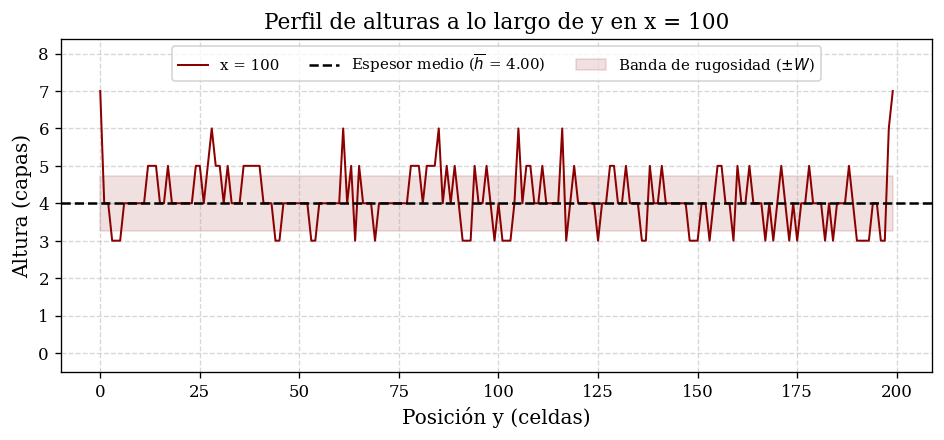

In [16]:
# Perfil unidimensional de la condición base: alturas a lo largo de y en la coordenada x central
x_central = NX // 2
perfil = superficie_base[x_central, :]
espesor_base = resumen_base["espesor"]
rugosidad_base = resumen_base["rugosidad"]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(perfil, color="darkred", linewidth=1.2, label=f"x = {x_central}")
ax.axhline(
    espesor_base, color="black", linestyle="--",
    label=rf"Espesor medio ($\overline{{h}}$ = {espesor_base:.2f})",
)
ax.fill_between(
    range(NY), espesor_base - rugosidad_base, espesor_base + rugosidad_base,
    color="darkred", alpha=0.12, label=r"Banda de rugosidad ($\pm W$)",
)
ax.set_title(f"Perfil de alturas a lo largo de y en x = {x_central}")
ax.set_xlabel("Posición y (celdas)")
ax.set_ylabel("Altura (capas)")
ax.grid(True, linestyle="--", alpha=0.5)
# Margen superior para que la leyenda no tape el perfil.
ax.set_ylim(min(perfil.min(), 0) - 0.5, perfil.max() + 0.35 * (perfil.max() - perfil.min()))
ax.legend(loc="upper center", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("angular_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

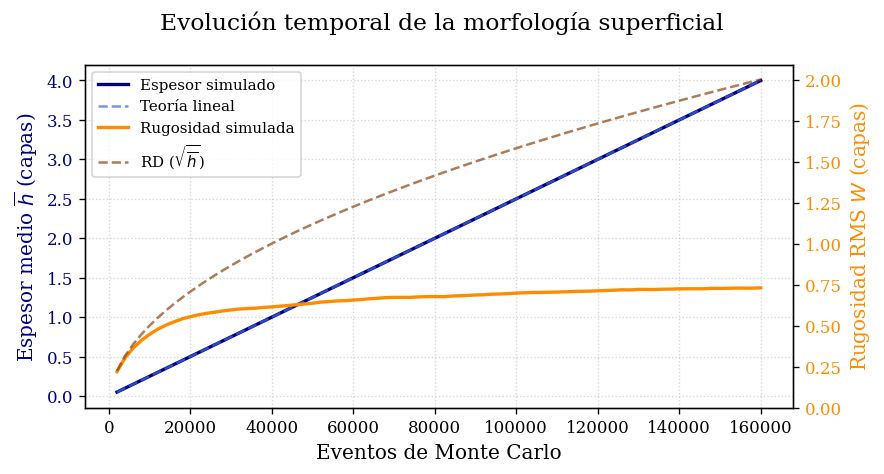

In [17]:
# Evolución temporal de la condición base
fig, ax1 = plt.subplots(figsize=(7.5, 4))

color_esp = "navy"
ax1.set_xlabel("Eventos de Monte Carlo")
ax1.set_ylabel(r"Espesor medio $\overline{h}$ (capas)", color=color_esp)
ax1.plot(hist_ev, hist_esp, color=color_esp, linewidth=2, label="Espesor simulado")
ax1.plot(hist_ev, hist_ev / n_celdas, "--", color="royalblue", alpha=0.7, label="Teoría lineal")
ax1.tick_params(axis="y", labelcolor=color_esp)
ax1.grid(True, linestyle=":", alpha=0.5)

# Segundo eje vertical para la rugosidad, cuya escala numérica es distinta.
ax2 = ax1.twinx()
color_rug = "darkorange"
ax2.set_ylabel(r"Rugosidad RMS $W$ (capas)", color=color_rug)
ax2.plot(hist_ev, hist_rug, color=color_rug, linewidth=2, label="Rugosidad simulada")
ax2.plot(
    hist_ev, np.sqrt(hist_ev / n_celdas), "--", color="saddlebrown", alpha=0.7,
    label=r"RD ($\sqrt{\overline{h}}$)",
)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=color_rug)

fig.suptitle("Evolución temporal de la morfología superficial")
fig.tight_layout()

# Una sola leyenda con las curvas de ambos ejes
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left", fontsize=9)
fig.savefig("angular_evolucion_temporal.png", bbox_inches="tight")
plt.show()

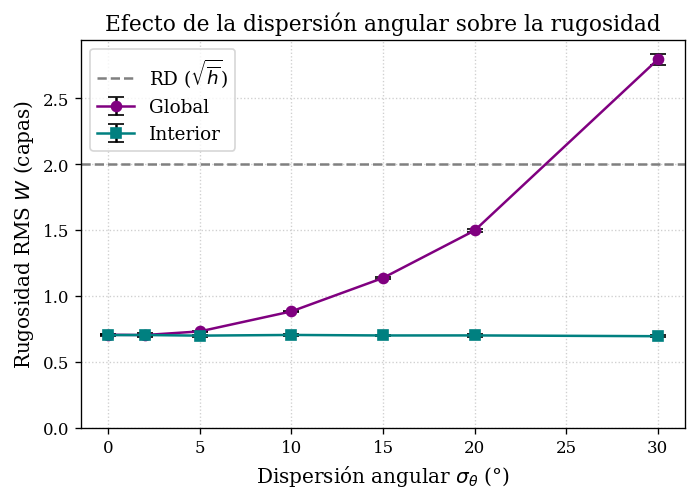

In [18]:
# Rugosidad global e interior frente a la dispersión angular
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(
    df_angulos["Sigma (°)"], df_angulos["Rugosidad global (capas)"],
    yerr=df_angulos["Desv. rugosidad global"], fmt="o-", color="purple", ecolor="black",
    capsize=5, lw=1.5, label="Global",
)
ax.errorbar(
    df_angulos["Sigma (°)"], df_angulos["Rugosidad interior (capas)"],
    yerr=df_angulos["Desv. rugosidad interior"], fmt="s-", color="teal", ecolor="black",
    capsize=5, lw=1.5, label="Interior",
)
ax.axhline(rugosidad_rd, color="gray", linestyle="--", label=r"RD ($\sqrt{\overline{h}}$)")
ax.set_xlabel(r"Dispersión angular $\sigma_\theta$ (°)")
ax.set_ylabel(r"Rugosidad RMS $W$ (capas)")
ax.set_ylim(bottom=0)
ax.set_title("Efecto de la dispersión angular sobre la rugosidad")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
fig.savefig("grafica_rugosidad_vs_sigma.png", bbox_inches="tight")
plt.show()

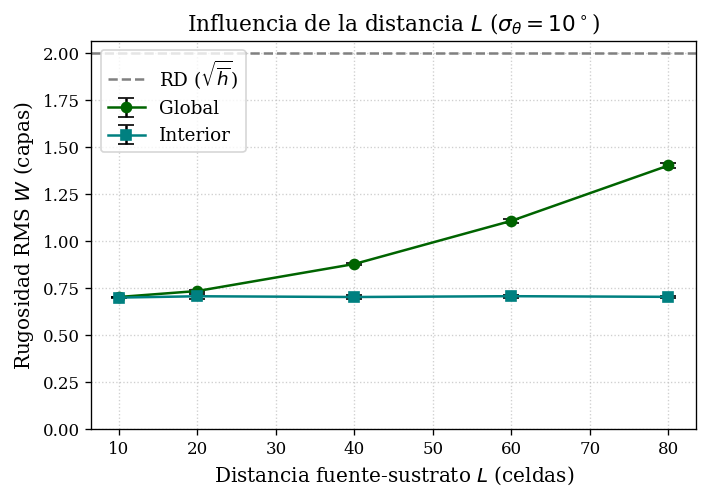

In [19]:
# Rugosidad global e interior frente a la distancia fuente-sustrato
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(
    df_distancias["Distancia L (celdas)"], df_distancias["Rugosidad global (capas)"],
    yerr=df_distancias["Desv. rugosidad global"], fmt="o-", color="darkgreen", ecolor="black",
    capsize=5, lw=1.5, label="Global",
)
ax.errorbar(
    df_distancias["Distancia L (celdas)"], df_distancias["Rugosidad interior (capas)"],
    yerr=df_distancias["Desv. rugosidad interior"], fmt="s-", color="teal", ecolor="black",
    capsize=5, lw=1.5, label="Interior",
)
ax.axhline(rugosidad_rd, color="gray", linestyle="--", label=r"RD ($\sqrt{\overline{h}}$)")
ax.set_xlabel(r"Distancia fuente-sustrato $L$ (celdas)")
ax.set_ylabel(r"Rugosidad RMS $W$ (capas)")
ax.set_ylim(bottom=0)
ax.set_title(rf"Influencia de la distancia $L$ ($\sigma_\theta = {SIGMA_FIJO}^\circ$)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
fig.savefig("grafica_rugosidad_vs_distancia.png", bbox_inches="tight")
plt.show()

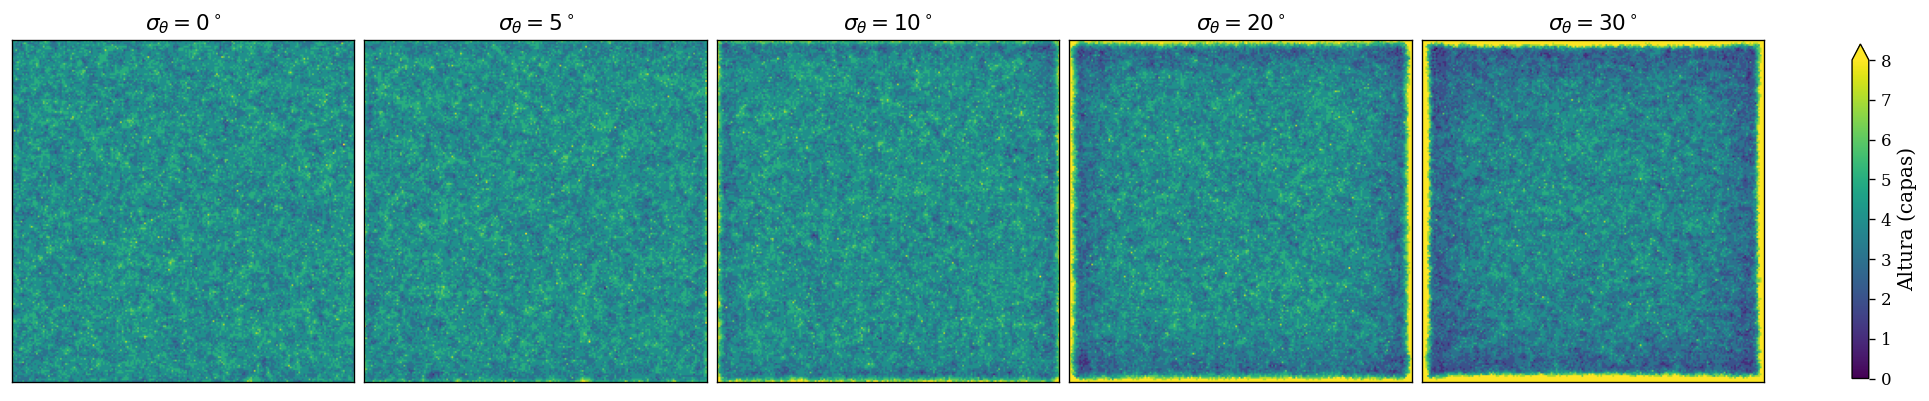

In [20]:
# Mapas topográficos a distintas dispersiones angulares, con una escala de color común
fig, axes = plt.subplots(1, len(SIGMAS_A_MOSTRAR), figsize=(16, 3.8), constrained_layout=True)
vmax_comun = 2 * espesor_teo      # escala saturada: las celdas de borde con más altura se ven en el color máximo

for ax, sigma in zip(axes, SIGMAS_A_MOSTRAR):
    # Se transpone la matriz para que el eje horizontal sea x (primer índice de la malla).
    imagen = ax.imshow(
        superficies_comparativas[sigma].T, origin="lower", cmap="viridis", vmin=0, vmax=vmax_comun
    )
    ax.set_title(rf"$\sigma_\theta = {sigma}^\circ$")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(imagen, ax=axes, shrink=0.75, extend="max", label="Altura (capas)")
fig.savefig("comparativa_topografica_angular.png", bbox_inches="tight")
plt.show()

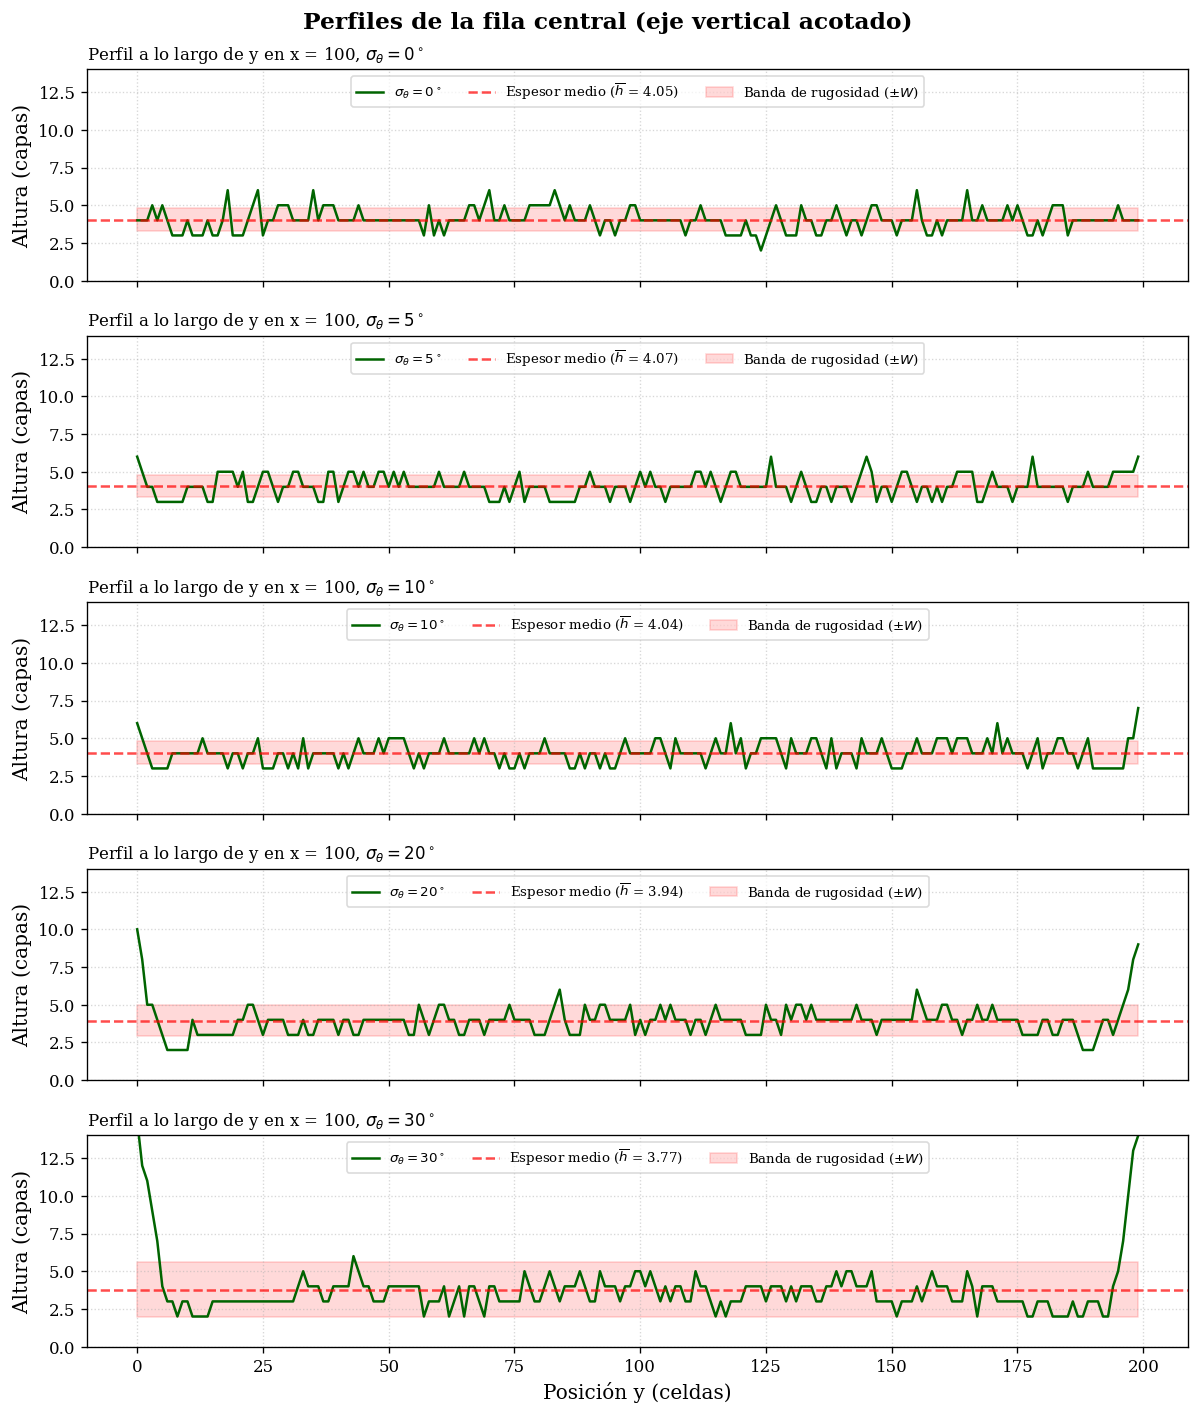

In [21]:
# Perfiles de la fila central, separados por dispersión angular
x_central = NX // 2
fig, axes = plt.subplots(len(SIGMAS_A_MOSTRAR), 1, figsize=(10, 12), sharex=True, sharey=True)

for ax, sigma in zip(axes, SIGMAS_A_MOSTRAR):
    perfil = superficies_comparativas[sigma][x_central, :]
    ax.plot(perfil, lw=1.5, color="darkgreen", label=rf"$\sigma_\theta = {sigma}^\circ$")
    ax.axhline(
        perfil.mean(), color="red", linestyle="--", alpha=0.7,
        label=rf"Espesor medio ($\overline{{h}}$ = {perfil.mean():.2f})",
    )
    ax.fill_between(
        range(NY), perfil.mean() - perfil.std(), perfil.mean() + perfil.std(),
        color="red", alpha=0.15, label=r"Banda de rugosidad ($\pm W$)",
    )
    ax.set_title(rf"Perfil a lo largo de y en x = {x_central}, $\sigma_\theta = {sigma}^\circ$", fontsize=10, loc="left")
    ax.set_ylabel("Altura (capas)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper center", ncol=3, fontsize=8, framealpha=0.7)

# Eje vertical acotado: los picos de las celdas de borde superan este rango.
axes[0].set_ylim(0, 3.5 * espesor_teo)
axes[-1].set_xlabel("Posición y (celdas)")
fig.suptitle("Perfiles de la fila central (eje vertical acotado)", fontweight="bold")
fig.tight_layout()
fig.savefig("comparativa_perfiles_centrales_subplots.png", bbox_inches="tight")
plt.show()

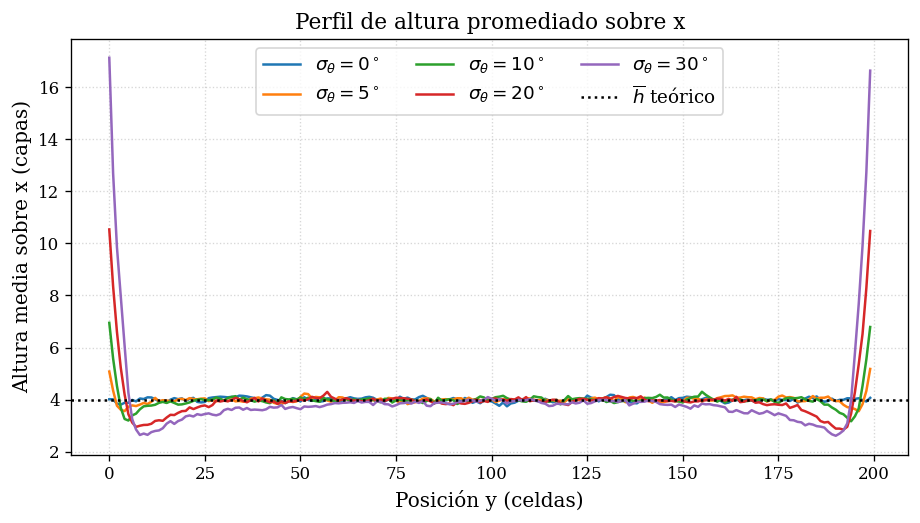

In [22]:
# Perfil de la altura media a lo largo de y, promediada sobre x
fig, ax = plt.subplots(figsize=(9, 4.5))
for sigma in SIGMAS_A_MOSTRAR:
    ax.plot(superficies_comparativas[sigma].mean(axis=0), label=rf"$\sigma_\theta = {sigma}^\circ$", lw=1.5)
ax.axhline(espesor_teo, color="black", linestyle=":", label=r"$\overline{h}$ teórico")
ax.set_xlabel("Posición y (celdas)")
ax.set_ylabel("Altura media sobre x (capas)")
ax.set_title("Perfil de altura promediado sobre x")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="upper center", ncol=3)
fig.savefig("comparativa_perfiles_promedio.png", bbox_inches="tight")
plt.show()

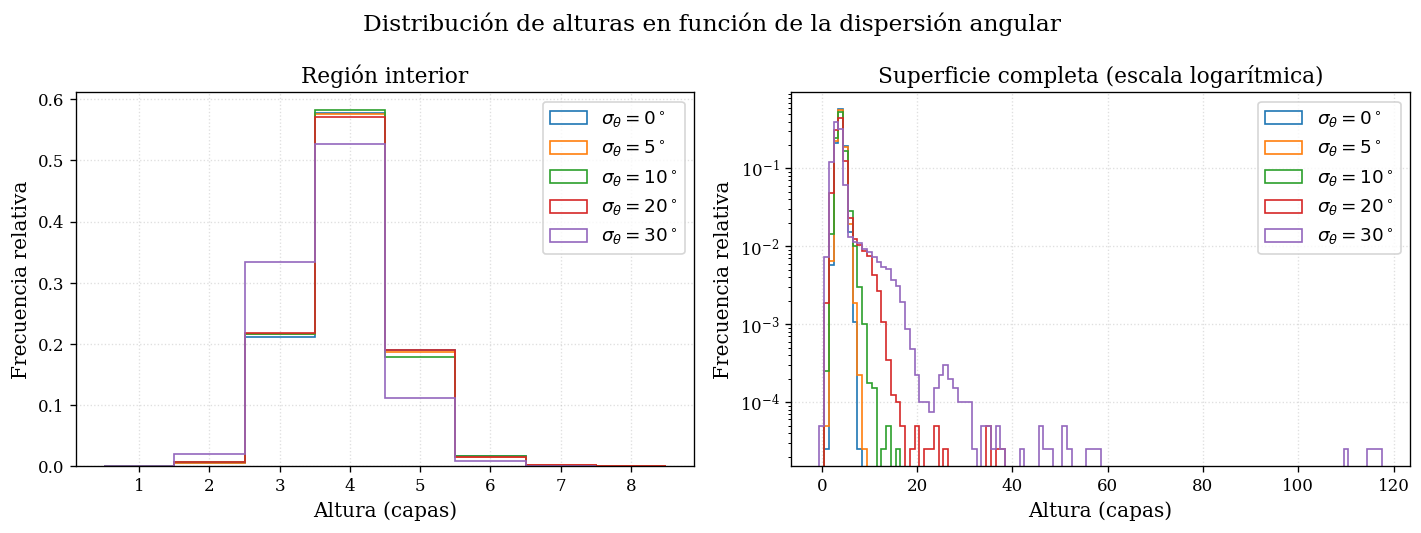

In [23]:
# Distribuciones de alturas a distintas dispersiones angulares: región interior y superficie completa
fig, (ax_int, ax_glob) = plt.subplots(1, 2, figsize=(12, 4.5))

for sigma in SIGMAS_A_MOSTRAR:
    superficie = superficies_comparativas[sigma]
    interior = superficie[MARGEN_INTERIOR:NX - MARGEN_INTERIOR, MARGEN_INTERIOR:NY - MARGEN_INTERIOR]

    # Un intervalo de anchura unidad por altura entera: con density=True, la altura
    # del escalón es la frecuencia relativa de esa altura.
    ax_int.hist(
        interior.ravel(), bins=np.arange(interior.min(), interior.max() + 2) - 0.5,
        density=True, histtype="step", lw=1.8, label=rf"$\sigma_\theta = {sigma}^\circ$",
    )
    ax_glob.hist(
        superficie.ravel(), bins=np.arange(superficie.min(), superficie.max() + 2) - 0.5,
        density=True, histtype="step", lw=1.8, label=rf"$\sigma_\theta = {sigma}^\circ$",
    )

ax_int.set_title("Región interior")
ax_glob.set_title("Superficie completa (escala logarítmica)")
ax_glob.set_yscale("log")
for ax in (ax_int, ax_glob):
    ax.set_xlabel("Altura (capas)")
    ax.set_ylabel("Frecuencia relativa")
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend()
fig.suptitle("Distribución de alturas en función de la dispersión angular")
fig.tight_layout()
fig.savefig("comparativa_histogramas_paso.png", bbox_inches="tight")
plt.show()

## 9. Análisis de resultados

### 9.1 Condición base

La condición base ($\sigma_\theta = 5^\circ$, $L = 40$, $T = 400$ K) deposita un espesor medio de 4 capas, exacto por conservación de partículas. Su rugosidad global, de unas 0.7 capas, es cerca de tres veces menor que la del modelo RD para ese espesor ($\sqrt{4} = 2$), porque la relajación por descenso suaviza la superficie de forma eficaz. La película cubre todo el sustrato sin celdas vacías. El anillo exterior contiene el 2 % de las celdas y recibe una fracción algo mayor de las partículas; la salida de la sección 6 informa las cifras de la realización ejecutada.

### 9.2 Influencia de la dispersión angular

La rugosidad global aumenta de forma continua con $\sigma_\theta$: de aproximadamente 0.70 capas sin dispersión a cerca de 2.8 capas con $\sigma_\theta = 30^\circ$, un valor incluso mayor que el de RD. La rugosidad interior, en cambio, se mantiene en torno a 0.70 capas para todos los valores de $\sigma_\theta$. El aumento de la rugosidad global no procede, por tanto, de un cambio de la morfología de la película, sino de los bordes. Las partículas cuya trayectoria las llevaría fuera de la malla se acumulan en las celdas de borde por el confinamiento, y las celdas contiguas quedan empobrecidas; ambos efectos se ven en el perfil de altura promediado y en la fracción de partículas del anillo exterior, que en la tabla del experimento I crece con $\sigma_\theta$.

Este resultado concuerda con la predicción de la sección 2.3: un desplazamiento aleatorio independiente no altera la distribución uniforme de los impactos en el interior. La validación de la sección 6 lo comprueba en el límite sin difusión, donde la rugosidad interior coincide con la de RD. Para $\sigma_\theta = 30^\circ$ la zona empobrecida llega a alcanzar el margen interior, y el espesor interior de la tabla queda ligeramente por debajo de 4 capas. Además, para $\sigma_\theta \geq 20^\circ$ la altura mínima media de la tabla baja de 1 capa, lo que indica celdas vacías en la zona empobrecida junto al borde.

### 9.3 Influencia de la distancia fuente-sustrato

La rugosidad global crece con $L$, de aproximadamente 0.70 capas con $L = 10$ a cerca de 1.4 capas con $L = 80$, mientras que la rugosidad interior permanece en torno a 0.70 capas. La causa es la misma que en el caso anterior. El desplazamiento lateral, $L \tan\theta$, es proporcional a $L$, de modo que una fracción creciente de las partículas resulta confinada en el borde, como muestra la columna de partículas en el anillo exterior.

### 9.4 Firmas morfológicas

Con una escala de color común, los mapas topográficos del interior son parecidos a todas las dispersiones y solo aparece un anillo brillante en el borde, con una banda más oscura contigua, cuando $\sigma_\theta$ es grande. Los perfiles de la fila central muestran, para dispersiones grandes, picos en los dos extremos que corresponden a las celdas de borde, y una región central que permanece dentro de la banda de rugosidad. En el histograma, la distribución del interior coincide para $\sigma_\theta \leq 20^\circ$ y se desplaza ligeramente hacia alturas menores para $30^\circ$, por el empobrecimiento que llega al margen interior. La distribución de la superficie completa desarrolla una cola de alturas muy grandes, cuyos máximos se alcanzan junto al borde y sobre todo en las esquinas, donde el confinamiento actúa en los dos ejes.

### 9.5 Alcance del modelo

El modelo confina en el borde las partículas que caerían fuera de la malla, y la dependencia de la rugosidad global con $\sigma_\theta$ y $L$ es consecuencia de esa elección. La distribución normal de los ángulos no está acotada, las distancias se miden en unidades de celda y la regla de difusión difiere de la del cuaderno 3. Por ello los resultados no describen la geometría de una cámara real. Para estudiarla haría falta otro tratamiento de los bordes y mecanismos sensibles a la dirección de llegada, como el sombreado geométrico.

## 10. Conclusiones

* Se implementó un operador de dispersión angular con desplazamiento $L \tan\theta$ en cada eje, combinado con una relajación térmica por descenso. La conservación del número de partículas se verifica en cada simulación y, sin difusión, el interior de la malla reproduce la estadística de RD.

* La rugosidad global crece con la dispersión angular y con la distancia fuente-sustrato, pero la rugosidad interior permanece constante en torno a 0.70 capas. El aumento procede del confinamiento de las partículas en los bordes de la malla y no de un cambio de la morfología de la película, porque un desplazamiento lateral aleatorio e independiente no modifica la distribución uniforme de los impactos en el interior.

* Para que la geometría de la cámara influya en la morfología hacen falta mecanismos sensibles a la dirección de llegada, como el sombreado, que no forman parte de este modelo. Los cuadernos siguientes de la serie incorporan mecanismos adicionales sobre esta base.

## 11. Referencias

**Fuentes académicas primarias**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.

* Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

* Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (LLVM '15) (Artículo 7, pp. 1–6). Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

* McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

* Nieuwenhuizen, J. M., & Haanstra, H. B. (1966). Microfractography of thin films. *Philips Technical Review, 27*, 87–91.

* Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

**Recursos complementarios**

* Numba. (s. f.). *Supported NumPy features*. Numba documentation. https://numba.pydata.org/numba-doc/latest/reference/numpysupported.html